# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ozair247/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

**Lane 2 — Refresh / Content Opportunity Scoring.**  
This notebook turns the validated Week‑5 model output into a practical, human‑reviewed
action playbook. It exports a ranked queue and a figure for the paper.

All data remains from `month=2026-03`. The sealed `month=2026-06` and `_sample` are not used.
No client names, URLs, or private queries appear anywhere.

In [7]:
%pip install -q duckdb scikit-learn pandas numpy matplotlib
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import userdata

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{userdata.get('HF_TOKEN')}')")

FACT_MONTH  = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet')"
DIM_CONTENT = "read_parquet('hf://datasets/FlyRank/internship-warehouse/dim_content.parquet')"

print("Connected.")

Connected.


Build feature frame

In [8]:
feature_frame = con.sql(f"""
    SELECT
        f.content_hash_id,
        f.client_hash_id,
        SUM(f.gsc_impressions)                                                            AS impressions_month,
        SUM(f.gsc_clicks)                                                                  AS clicks_month,
        AVG(NULLIF(f.gsc_avg_position, 0))                                                 AS avg_position_month,
        SUM(f.gsc_clicks) / NULLIF(SUM(f.gsc_impressions), 0) * 100                        AS ctr_month,
        SUM(CASE WHEN f.ga4_data_available THEN f.ga4_engaged_sessions ELSE 0 END)         AS engaged_sessions_month,
        SUM(CASE WHEN f.ga4_data_available THEN f.ga4_sessions ELSE 0 END)                 AS sessions_month,
        MAX(CASE WHEN f.ga4_data_available THEN 1 ELSE 0 END)                              AS has_ga4_month,
        DATE_DIFF('day', ANY_VALUE(c.content_created_date), DATE '2026-03-31')             AS content_age_days,
        ANY_VALUE(c.word_count)                                                            AS word_count,
        SUM(CASE WHEN f.report_date >= DATE '2026-03-16' THEN f.gsc_impressions ELSE 0 END) AS impr_last15,
        SUM(CASE WHEN f.report_date <  DATE '2026-03-16' THEN f.gsc_impressions ELSE 0 END) AS impr_prev15
    FROM {FACT_MONTH} f
    LEFT JOIN {DIM_CONTENT} c ON f.content_hash_id = c.content_hash_id
    GROUP BY f.content_hash_id, f.client_hash_id
    HAVING SUM(f.gsc_impressions) > 0
""").df()

feature_frame = feature_frame.dropna(subset=["content_age_days"]).reset_index(drop=True)

feature_frame["is_declining_proxy"] = (
    (feature_frame["impr_prev15"] > 0)
    & ((feature_frame["impr_last15"] - feature_frame["impr_prev15"]) / feature_frame["impr_prev15"] < -0.20)
).astype(int)

feature_frame["engagement_rate_month"] = np.where(
    feature_frame["sessions_month"] > 0,
    feature_frame["engaged_sessions_month"] / feature_frame["sessions_month"] * 100,
    0.0,
)
feature_frame["has_word_count"] = feature_frame["word_count"].notna().astype(int)
feature_frame["word_count"] = feature_frame["word_count"].fillna(0)

print(f"Rows: {len(feature_frame)}")
feature_frame.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 176738


,content_hash_id,client_hash_id,impressions_month,clicks_month,avg_position_month,ctr_month,engaged_sessions_month,sessions_month,has_ga4_month,content_age_days,word_count,impr_last15,impr_prev15,is_declining_proxy,engagement_rate_month,has_word_count
0,content_67741cce996cfafa,client_62f4a7e64f5e0096,46.0,1.0,5.942308,2.173913,0.0,0.0,0,47,3057,8.0,38.0,1,0.0,1
1,content_2e6360ad20fd7107,client_62f4a7e64f5e0096,899.0,1.0,5.908100,0.111235,0.0,0.0,0,47,2855,680.0,219.0,0,0.0,1
2,content_65c50dfe9d87a585,client_62f4a7e64f5e0096,3108.0,0.0,6.969536,0.000000,0.0,0.0,0,47,2779,1614.0,1494.0,0,0.0,1
3,content_275b6f7f733016d4,client_62f4a7e64f5e0096,810.0,1.0,4.866123,0.123457,0.0,0.0,0,47,3653,343.0,467.0,1,0.0,1
4,content_4dc944b7d0b65ecc,client_62f4a7e64f5e0096,134.0,0.0,5.012831,0.000000,0.0,0.0,0,47,3698,64.0,70.0,0,0.0,1


## 1. Ranked actions + reason codes

The queue below is built from the same Random Forest model used in Week 5.  
Each row gets an **action label** and a **single reason code** so a human reviewer can
immediately see why it is ranked where it is.

**Action logic:**
- `review_for_refresh` — high model risk **and** enough visibility to be worth a review.
- `monitor` — moderate risk or lower visibility, but not zero.
- `no_action` — low risk or invisible.

**Reason codes:**
- `high_risk_visible` — top decile of predicted decline risk with ≥ 500 impressions.
- `high_risk_low_traffic` — top decile risk but < 500 impressions.
- `moderate_risk_visible` — middle risk band with ≥ 500 impressions.
- `low_risk_or_invisible` — everything else.

In [9]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

FEATURES = [
    "content_age_days", "impressions_month", "ctr_month", "avg_position_month",
    "engagement_rate_month", "has_ga4_month", "word_count", "has_word_count",
]

X = feature_frame[FEATURES].copy()
for col in ["avg_position_month", "ctr_month"]:
    X[col] = X[col].fillna(0)

y = feature_frame["is_declining_proxy"]

# Train on full March 2026 frame for ranking purposes only.
# The model was validated in Week 5 on a grouped split; using it here is decision-support,
# not a performance claim.
rf = RandomForestClassifier(
    n_estimators=300, max_depth=6, min_samples_leaf=20,
    random_state=42, n_jobs=1
)
rf.fit(X, y)

feature_frame["model_risk_score"] = rf.predict_proba(X)[:, 1]

# Rank and assign action + reason code (vectorized)
queue = feature_frame.copy()
queue = queue.sort_values("model_risk_score", ascending=False).reset_index(drop=True)
queue["rank"] = np.arange(1, len(queue) + 1)

q90 = np.quantile(queue["model_risk_score"], 0.90)
q75 = np.quantile(queue["model_risk_score"], 0.75)

high_risk = queue["model_risk_score"] >= q90
moderate_risk = (queue["model_risk_score"] >= q75) & ~high_risk
visible = queue["impressions_month"] >= 500

queue["action"] = np.select(
    [high_risk & visible,
     high_risk & ~visible,
     moderate_risk & visible],
    ["review_for_refresh", "monitor", "monitor"],
    default="no_action"
)

queue["reason_code"] = np.select(
    [queue["action"] == "review_for_refresh",
     (queue["action"] == "monitor") & high_risk,
     (queue["action"] == "monitor") & moderate_risk],
    ["high_risk_visible", "high_risk_low_traffic", "moderate_risk_visible"],
    default="low_risk_or_invisible"
)

print(queue["action"].value_counts())
print(queue["reason_code"].value_counts())
queue[["rank", "content_hash_id", "client_hash_id", "model_risk_score",
       "action", "reason_code", "content_age_days", "impressions_month",
       "ctr_month", "avg_position_month", "is_declining_proxy"]].head(10)

action
no_action             155542
monitor                20508
review_for_refresh       688
Name: count, dtype: int64
reason_code
low_risk_or_invisible    155542
high_risk_low_traffic     16986
moderate_risk_visible      3522
high_risk_visible           688
Name: count, dtype: int64


,rank,content_hash_id,client_hash_id,model_risk_score,action,reason_code,content_age_days,impressions_month,ctr_month,avg_position_month,is_declining_proxy
0,1,content_d53e6d6d86dee421,client_3ffa76342f366962,0.515452,monitor,high_risk_low_traffic,223,1.0,100.0,6.0,1
1,2,content_2ef804797511cff9,client_2b4306c3ed003f01,0.513862,monitor,high_risk_low_traffic,200,1.0,100.0,6.0,1
2,3,content_2751cdb2dea8caf4,client_3ffa76342f366962,0.512460,monitor,high_risk_low_traffic,214,1.0,100.0,4.0,1
3,4,content_6b358196cdd19187,client_3ffa76342f366962,0.511513,monitor,high_risk_low_traffic,216,1.0,100.0,3.0,1
4,5,content_0037bd46b0bb982b,client_3ffa76342f366962,0.511192,monitor,high_risk_low_traffic,210,1.0,100.0,3.0,1
5,6,content_7782cd9c7533cbe1,client_2b4306c3ed003f01,0.511078,monitor,high_risk_low_traffic,198,1.0,100.0,10.0,1
6,7,content_98f1f88d044bcb7e,client_3ffa76342f366962,0.510919,monitor,high_risk_low_traffic,214,1.0,100.0,1.0,1
7,8,content_1878b8b9be0284e2,client_3ffa76342f366962,0.510364,monitor,high_risk_low_traffic,217,1.0,100.0,NaN,1
8,9,content_bec4846b0f3b2143,client_3ffa76342f366962,0.509244,monitor,high_risk_low_traffic,213,1.0,100.0,1.0,1
9,10,content_7c3db3263d57629d,client_3ffa76342f366962,0.509155,monitor,high_risk_low_traffic,229,1.0,100.0,1.0,1


**Archetype → action mapping** used above:

| Archetype | Typical features | Action |
|---|---|---|
| Old + visible + high model risk | age ≥ 180, impressions ≥ 500, top‑decile score | `review_for_refresh` |
| Old + visible + moderate risk | age ≥ 180, impressions ≥ 500, 75th‑90th percentile score | `monitor` |
| Old + invisible | age ≥ 180, impressions < 500, high score | `monitor` / `no_action` |
| Young + slipping | age < 180, high score, visible | `monitor` (not a staleness story) |
| Young + stable / low risk | age < 180, low score | `no_action` |

**Decay / refresh insight:**  
Very old pages do not always have the highest decline rate. The risk model weights
`content_age_days` most, but also `impressions_month` and `avg_position_month`.
The playbook therefore does **not** auto‑flag every old page; it flags old pages that are
still visible and show decline‑like patterns.

## 2. Intended use and limits

**Who uses this:**  
A content strategist or SEO analyst on Lane 2. They open the queue, start with the top rows,
and decide which pages to review for refresh.

**What it is for:**  
Prioritizing a human review queue — not making the final decision.

**Where it stops being valid:**
- It was built on March 2026 data only. Performance on a later month is not guaranteed.
- It uses a proxy label (`is_declining_proxy`) that measures within‑month decline, not true future decay.
- It does not see content quality, brand context, or editorial calendar.
- It was trained on the same warehouse used for feature creation; deployment on a new client or
  a different time period requires retraining or recalibration.

## 3. Human review + the no-go list

Before acting on any row, a human must check:
- Is the page actually live and indexable? (not deleted / redirected)
- Is the traffic decline due to seasonality, a known site migration, or an algorithm update?
- Does the page already have an editorial update scheduled?
- Is the page brand‑driven, where staleness is irrelevant?
- Does the content still satisfy search intent even if it is old?

**What should never be automated:**
- Auto‑publishing edits or refreshed content.
- Auto‑changing titles/meta descriptions.
- Auto‑removing or redirecting pages.
- Auto‑recommending actions to clients without human sign‑off.
- Auto‑sending reports that contain client names or URLs to external audiences.

## 4. Monitoring / retrain triggers

Lightweight triggers that would tell us the recommendations went stale:

1. **Precision drop:** If the model’s held‑out `precision@50` falls below **0.30**, or
   below the Week‑4 baseline on the same split, the queue is no longer better than the rule.
2. **False positive rate rise:** If the top 50 false positive rate exceeds **50%** on a fresh
   month, the model may be over‑flagging old pages.
3. **Feature distribution drift:** If the share of content items older than 365 days changes
   by more than **20%** from the March 2026 reference, retrain or rebucket.
4. **Client churn:** If the client set changes substantially (new clients, lost GSC/GA4 access),
   the model may need re‑fitting.

**Retrain cadence:** monthly or quarterly, on a mid‑panel month, never on the sealed final month.

## 5. Exports for the paper

The ranked queue is written to `work/outputs/w07_action_queue.csv`.  
A simple figure of action distribution is saved to `work/figures/w07_action_distribution.png`
for reuse in the paper.

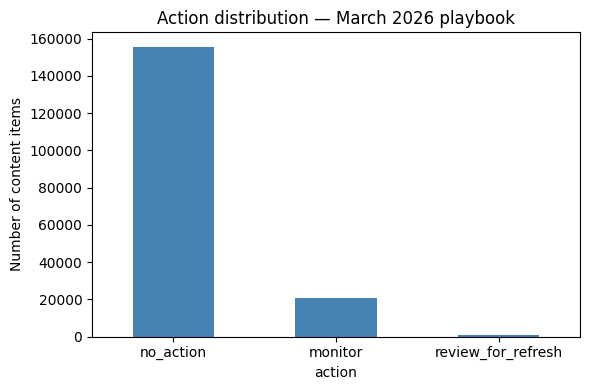

Exported:
- work/outputs/w07_action_queue.csv
- work/figures/w07_action_distribution.png


In [10]:
import os

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

export_cols = [
    "rank", "content_hash_id", "client_hash_id", "model_risk_score",
    "action", "reason_code", "content_age_days", "impressions_month",
    "ctr_month", "avg_position_month", "is_declining_proxy"
]

# 1) Write ranked queue CSV
queue[export_cols].to_csv("work/outputs/w07_action_queue.csv", index=False)

# 2) Action distribution figure
action_counts = queue["action"].value_counts()
plt.figure(figsize=(6, 4))
action_counts.plot(kind="bar", color="steelblue")
plt.title("Action distribution — March 2026 playbook")
plt.ylabel("Number of content items")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("work/figures/w07_action_distribution.png", dpi=120)
plt.show()

print("Exported:")
print("- work/outputs/w07_action_queue.csv")
print("- work/figures/w07_action_distribution.png")

## Self-check

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.